# Test `NeuralPDE` notebook

From: [this tutorial example](https://docs.sciml.ai/NeuralPDE/stable/tutorials/integro_diff)

twnh Jun '25

# Solving Integro-Differential Equations with Physics-Informed Neural Networks (PINNs)

The integral of function ``u(x)``,

```math
\int_{0}^{t}u(x)dx
```

where ``x`` is variable of integral and ``t`` is variable of integro-differential equation, is defined as

```julia
using ModelingToolkit
@parameters t
@variables i(..)
Ii = Symbolics.Integral(t in DomainSets.ClosedInterval(0, t))
```

In multidimensional case,

```julia
Ix = Integral((x, y) in DomainSets.UnitSquare())
```

The UnitSquare domain ranges both x and y from 0 to 1.
Similarly, a rectangular or cuboidal domain can be defined using `ProductDomain` of ClosedIntervals.

```julia
Ix = Integral((x, y) in DomainSets.ProductDomain(ClosedInterval(0, 1), ClosedInterval(0, x)))
```

## 1-dimensional example

Let's take an example of an integro-differential equation:

```math
\frac{∂}{∂t} u(t)  + 2u(t) + 5 \int_{0}^{t}u(x)dx = 1 \ \text{for} \ t \geq 0
```

and boundary condition

```math
u(0) = 0
```


In [1]:
using NeuralPDE, Lux, ModelingToolkit, Optimization, OptimizationOptimJL, DomainSets
using ModelingToolkit: Interval, infimum, supremum
using Plots

@parameters t
@variables i(..)
Di = Differential(t)
Ii = Integral(t in DomainSets.ClosedInterval(0, t))
eq = Di(i(t)) + 2 * i(t) + 5 * Ii(i(t)) ~ 1
bcs = [i(0.0) ~ 0.0]
domains = [t ∈ Interval(0.0, 2.0)]
chain = Lux.Chain(Lux.Dense(1, 15, Lux.σ), Lux.Dense(15, 1))

strategy_ = QuadratureTraining()
discretization = PhysicsInformedNN(chain,
    strategy_)
@named pde_system = PDESystem(eq, bcs, domains, [t], [i(t)])
prob = NeuralPDE.discretize(pde_system, discretization)
callback = function (p, l)
    println("Current loss is: $l")
    return false
end
res = Optimization.solve(prob, BFGS(); maxiters = 100)

retcode: Failure
u: ComponentVector{Float64}(layer_1 = (weight = [1.660652388349334; 0.5009130439509137; … ; -1.9866722767926372; -2.165180155127525;;], bias = [0.9364760107093252, -0.607724109691852, 0.24565656875897504, 0.5266339834745868, -0.6934125034458202, 0.04956781859091241, 1.057254785870574, 0.5823752008073513, -0.6696288639261804, 0.9404606045155512, -0.2088070711071889, 0.6319754663684499, 0.9428696630362736, 1.9586966932825722, -1.0271684705581545]), layer_2 = (weight = [0.3778688331364598 0.8016203618436748 … 0.9399103256423296 -1.2221833377224236], bias = [-0.48216163731549416]))

Plotting the final solution and analytical solution

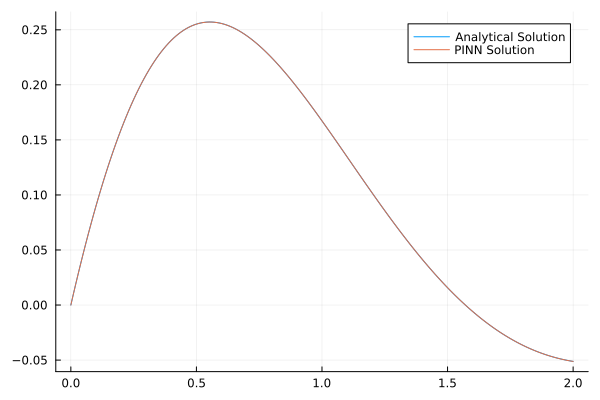

In [2]:
ts = [infimum(d.domain):0.01:supremum(d.domain) for d in domains][1]
phi = discretization.phi
u_predict = [first(phi([t], res.u)) for t in ts]

analytic_sol_func(t) = 1 / 2 * (exp(-t)) * (sin(2 * t))
u_real = [analytic_sol_func(t) for t in ts]
plot(ts, u_real, label = "Analytical Solution")
plot!(ts, u_predict, label = "PINN Solution")